In [61]:
# Hello! I am a test cell. You can run me to see if your Python environment is working.
# Try pressing 'Ctrl + Enter' and see if you can see the message below.

print("If it is working, it is working. If it is not, it is not.")

If it is working, it is working. If it is not, it is not.


### The Histogram

A histogram is a graphical representation of the distribution of a dataset, showing the frequency or relative frequency within intervals. Therefore, the bars represent the **data count** in each interval.

It works by:
- partitioning the spread of the numeric data into bins,
- assigning each data point in the dataset to a bin,
- and then counting the number of data points assigned to each bin.

**The vertical axis essentially represents the frequency or the number of data points in each bin.**

**Use cases:**

- Histograms offer valuable insights into data distribution, outliers, skewness, and variability. They visually depict the shape of the data, whether it's symmetric, skewed, or bimodal. Skewness can be assessed by examining the histogram's shape.
- Histograms also showcase data variability, allowing you to observe concentrations, gaps, and clusters that reveal patterns or subgroups.

**be careful while choosing the bins to create a histogram.!**

# Graph Aesthetics

### Edge Color

As with bar plots, to define the color of the edge, we use the `edgecolor` variable:

```python
plt.hist(data, bins=bins, color='skyblue', edgecolor='black') 
```

### Grid Lines

Similar to line and bar plots, we can also define grids for our histogram. A good option is to use a distinct color and linestyle (similar to MATLAB style). To do this, we can use:

```python
# Add grid lines similar to MATLAB style
plt.grid(color='white', linestyle='-', linewidth=2)
plt.gca().set_axisbelow(True)  # Ensure grid lines are behind the bars
plt.gca().set_facecolor('#E5E5E5')  # Set the axes background color
```

### numpy.histogram

The `numpy.histogram` function is a versatile tool for computing histograms of datasets in Python. Unlike plotting libraries like matplotlib, which visually represent histograms, `numpy.histogram` is used for calculating the histogram's numerical values, making it particularly useful for data analysis tasks where you need to manipulate or examine the histogram data directly.

```python
import numpy as np

hist, bin_edges = np.histogram(data, bins=10)
```

**Tip**: The `bin_edges` can be used to fix the position of the xticks in your histogram.

### Bin Size

One of the most important aspects when generating a histogram is to correctly place the bars among the bins. This is necessary because it facilitates the reading of the data distribution and makes your plot readable.

In the case of a histogram, bar placement is a bit trickier since it depends on the bins you define. Depending on the data you have, sometimes you need to create the bins yourself instead of letting matplotlib do it. For these cases, instead of giving the **size** of the bin to `plt.hist`, you can give a **list** that represents the bins.

```python
bins = np.arange(min_v, max_v + 1, 5)  # +1 ensures the last bin is included
# min_v and max_v are the minimum and maximum values in your dataset
plt.hist(data, bins=bins, color='skyblue', edgecolor='black') 
```


In [62]:
# Let's take a look at histogram generation.
# First, let's generate a dataset representing the ages of 1000 people in a city.
import numpy as np

# Normal distribution - mean (μ) of 50, standard deviation (σ) of 15
data = np.random.normal(50, 15, 1000)

# Uniform distribution - minimum of 0, maximum of 100
# data = np.random.uniform(0, 100, 1000)


# Now, let's examine the age distribution of these people.



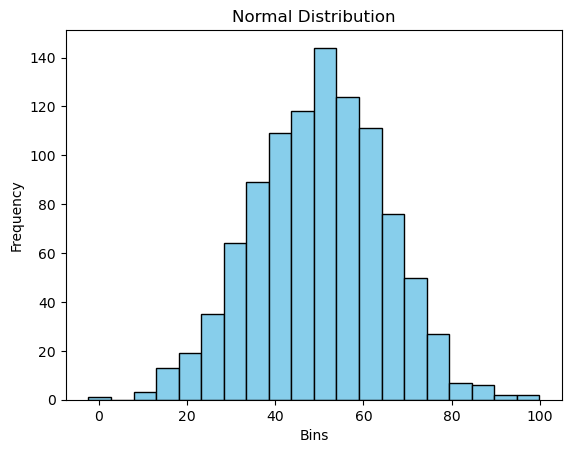

In [63]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(data, bins=20, edgecolor='black', color = 'skyblue')

plt.title("Normal Distribution")
plt.xlabel("Bins")
plt.ylabel("Frequency")

plt.show()


In [72]:

import matplotlib.pyplot as plt
import numpy as np

count, bins_edge = np.histogram(data, bins=20)

print(count)
print(bins_edge)



[2 1 3 1 2 3 3 1 2 2 2 6 3 1 2 7 2 1 2 4]
[0.01294066 0.06125968 0.10957871 0.15789773 0.20621676 0.25453578
 0.30285481 0.35117383 0.39949286 0.44781188 0.49613091 0.54444993
 0.59276896 0.64108798 0.68940701 0.73772603 0.78604506 0.83436408
 0.88268311 0.93100213 0.97932116]


In the previous graph, your data represent ages, but the bins show float numbers. This occurred due to the bin size we are using. This example demonstrates the impact of bin size on data visualization. How could we define bins that make sense for the data we are analyzing? For instance, how about defining bins every 5 years?


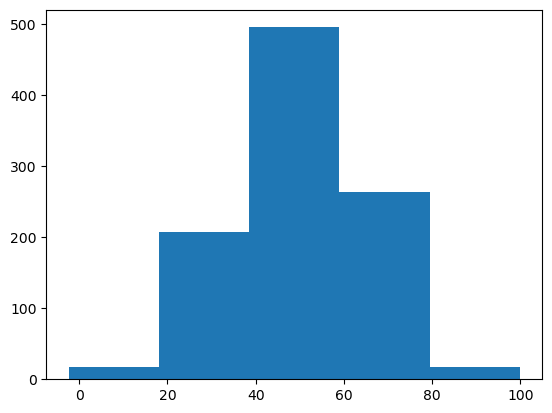

In [ ]:
# Do the previous histogram but now considering bins of 5 years.


# Activity 01

Considering the DataScience Salaries dataset, create a histogram to display the salary distribution (using the column `salary_in_usd`). Utilize a fixed bin size of 10.

The graph should include:

1. A title and axis labels.
2. A legend.
3. All bins positioned accurately and in a manner that ensures readability.
4. Enhanced visualization with a MATLAB-like grid.

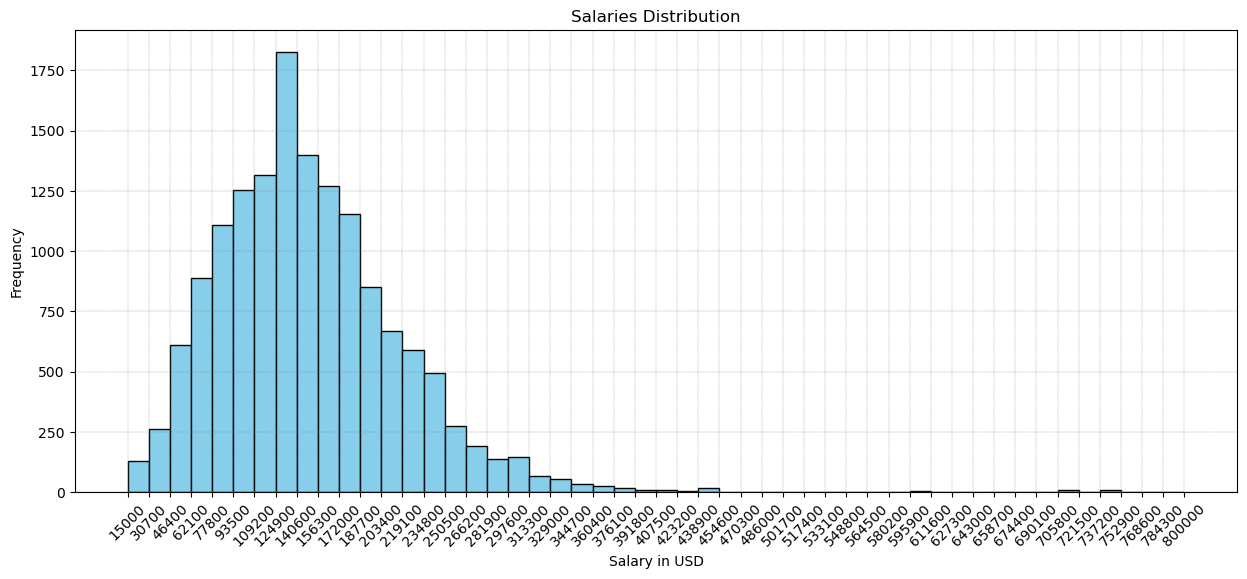

In [103]:
# Do the activity 01 here
df = pd.read_csv("DataScience_salaries_2024.csv")

data = df["salary_in_usd"]
count, bins_edge = np.histogram(data, bins=50)
plt.figure(figsize=(15, 6))
plt.hist(data, bins=50, edgecolor='black', color = 'skyblue')
plt.title("Salaries Distribution")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.xticks(bins_edge, rotation=45)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.25)

plt.show()

# Activity 02

Now, do the same histogram as before, but using a fixed salary interval of 50000 dolares.

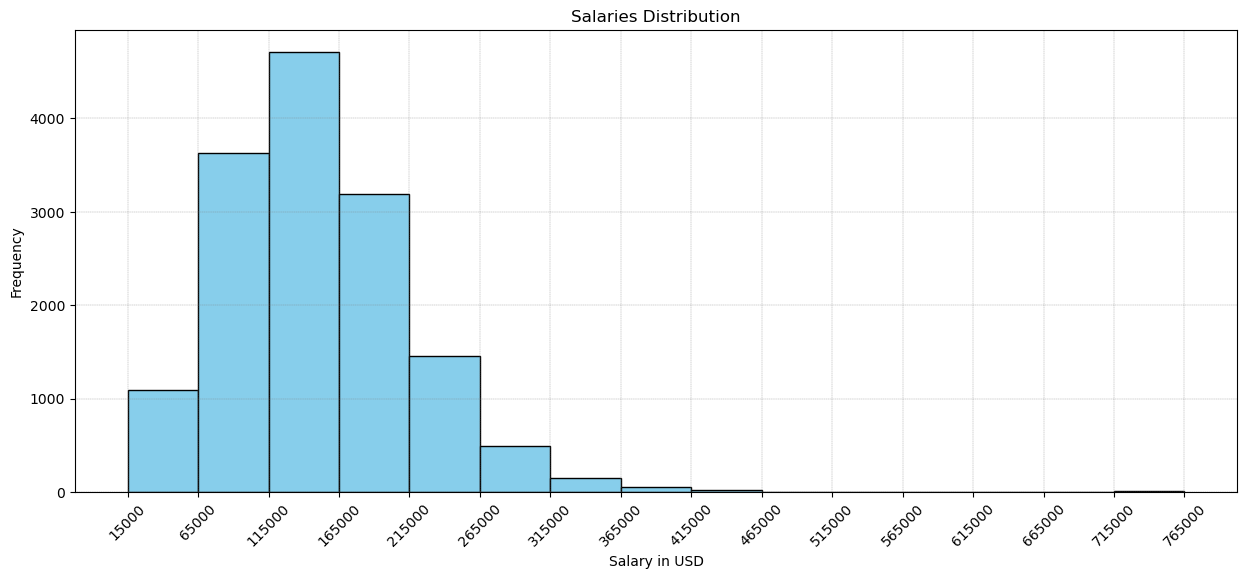

In [107]:
# Do the activity 02 here
bins = range(data.min(), data.max() + 1, 50000)
plt.figure(figsize=(15, 6))
plt.hist(data, bins=bins, edgecolor='black', color = 'skyblue')
plt.title("Salaries Distribution")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.xticks(bins, rotation=45)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.25)

plt.show()


# Box Plots

A box plot is a way to statistically represent the distribution of given data through five primary dimensions:

1. **Minimum**: The smallest number in the sorted data.
2. **First Quartile**: The point 25% of the way through the sorted data. In other words, a quarter of the data points are less than this value.
3. **Median**: The median of the sorted data.
4. **Third Quartile**: The point 75% of the way through the sorted data. In other words, three quarters of the data points are less than this value.
5. **Maximum**: The highest number in the sorted data.


# Graph Aesthetics

### Box Color and Edge

To customize the appearance of the box in a boxplot, use the `patch_artist=True` setting along with `boxprops`. This allows the box to be filled with color. The `edgecolor` and other properties can also be defined in `boxprops`:

```python
plt.boxplot(data, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black', linewidth=1.5))
```

### Whisker Lines

Whiskers in a boxplot visually represent the variability outside the upper and lower quartiles. You can customize their color and width using `whiskerprops`:

```python
plt.boxplot(data, whiskerprops=dict(color='black', linewidth=1.5))
```

### Cap Lines

Caps are the horizontal lines at the ends of the whiskers. Adjust their color and width to enhance the boxplot’s clarity using `capprops`:

```python
plt.boxplot(data, capprops=dict(color='black', linewidth=1.5))
```

### Outlier Markers

Outliers are visualized as individual points in a boxplot. Customize these using `flierprops`, which can define the marker style, color, size, and line style:

```python
plt.boxplot(data, flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none'))
```

### Median Line

The median line is a key component of the boxplot, highlighting the median of the dataset. Its appearance can be adjusted with `medianprops`:

```python
plt.boxplot(data, medianprops=dict(color='black', linewidth=1.5))
```

### Setting Background Color and Grid Lines

Setting the axes' background color and adding grid lines can improve the readability and visual appeal of your boxplot:

```python
plt.grid(color='white', linestyle='-', linewidth=2)
plt.gca().set_axisbelow(True)  # Ensure grid lines are behind the plot elements
plt.gca().set_facecolor('#E5E5E5')  # Set the axes background color
```


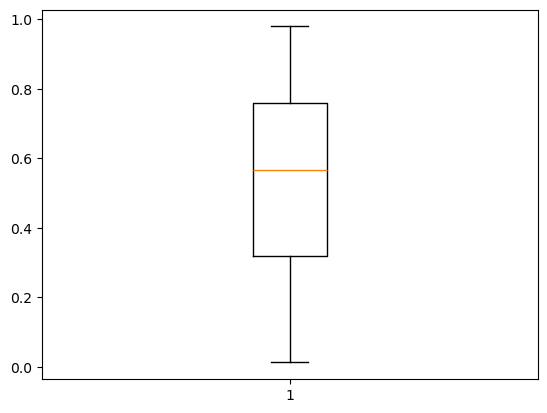

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = np.random.rand(50)

# Create a boxplot
plt.boxplot(data)

# Show the plot
plt.show()


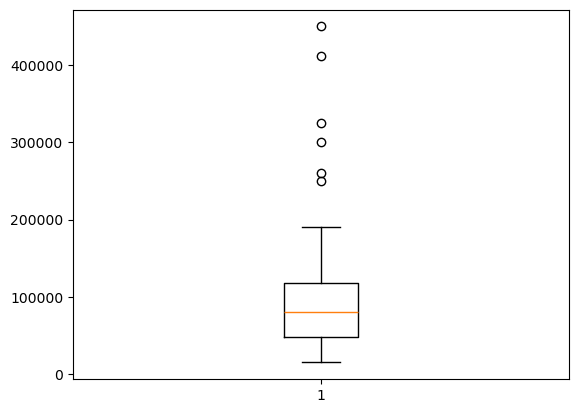

In [112]:
# Exercise 01: Plot the Box Plot of the Salaries of Data Scientists in 2020


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('DataScience_salaries_2024.csv')

data = df[df['work_year'] == 2020]['salary_in_usd']
plt.boxplot(data)
plt.show()


/var/folders/j0/_nt_yhqd1wsdc65yzzgxw4d00000gn/T/ipykernel_61699/1490054270.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_2020, data_2021, data_2022, data_2023], labels=['2020', '2021', '2022', '2023'])


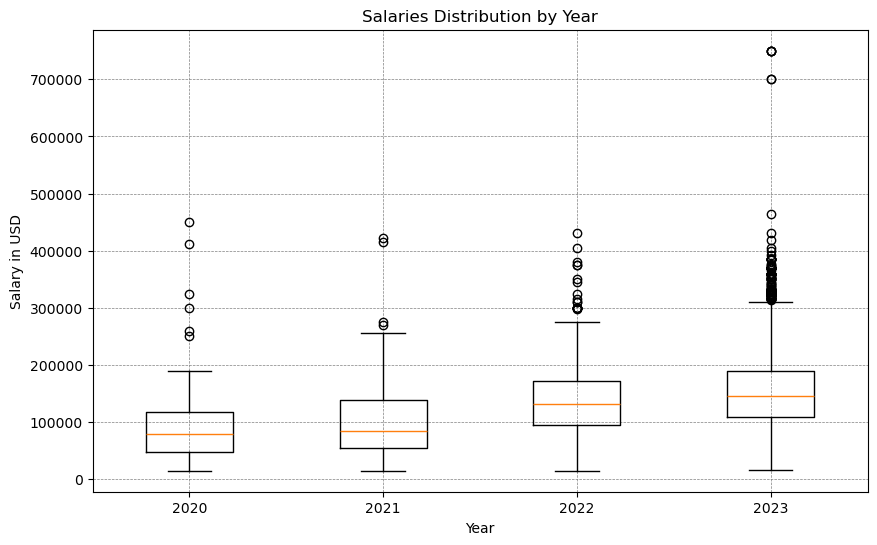

In [ ]:
# Exercise 02: In the boxplot above, add the years 2021, 2022, and 2023. Make a very nice plot using aesthetic features.
data_2020 = df[df['work_year'] == 2020]['salary_in_usd']
data_2021 = df[df['work_year'] == 2021]['salary_in_usd']
data_2022 = df[df['work_year'] == 2022]['salary_in_usd']
data_2023 = df[df['work_year'] == 2023]['salary_in_usd']

plt.figure(figsize=(10, 6))
plt.boxplot([data_2020, data_2021, data_2022, data_2023], labels=['2020', '2021', '2022', '2023'])
plt.title("Salaries Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Salary in USD")
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()